Major League Baseball (MLB) changed several rules between the 2022 and 2023 seasons that included the following:

1) Larger bases (15 to 18 inches) -> Easier target for batters to earn a base on a hit or steal
2) A runner will start on 2nd base for each team in extra innings -> Each team should be able to score more runs easily by starting each extra inning with a runner in scoring position
3) Defensive shifts are not allowed -> Teams are no longer able to make extreme shifts in order to defensively align for particular batter strengths/weaknesses
4) Pitch clocks implemented -> Though this is mostly a pace-of-play implementation for shorter games, it takes some of the control away from the pitcher by forcing him to throw each pitch according to a timer

This Notebook is a simple exploration of how these rule changes might have impacted scoring between the 2022 and 2023 seasons in the MLB (regular season games only). The main question is: Did these rule changes help increase run scoring or make no difference?

In [8]:
# Imports
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, levene, mannwhitneyu
import matplotlib.pyplot as plt

# Data (obtained/cleaned w/ scripts in this repo
df = pd.read_csv('../data/games_clean.csv')
print(f"Loaded {len(df)} games")
print(df.head())

Loaded 4860 games
   game_id        date             home_team            away_team  home_score  \
0   663178  2022-04-07          Chicago Cubs    Milwaukee Brewers           5   
1   662766  2022-04-07    Kansas City Royals  Cleveland Guardians           3   
2   662021  2022-04-07   St. Louis Cardinals   Pittsburgh Pirates           9   
3   662571  2022-04-07  Washington Nationals        New York Mets           1   
4   661577  2022-04-07        Atlanta Braves      Cincinnati Reds           3   

   away_score  year  total_score  
0           4  2022            9  
1           1  2022            4  
2           0  2022            9  
3           5  2022            6  
4           6  2022            9  


Summary dataframe:
      n_games  total_runs  avg_runs  std_runs
year                                         
2022     2430       20817  8.566667  4.392942
2023     2430       22432  9.231276  4.583700
Index: [2022, 2023]


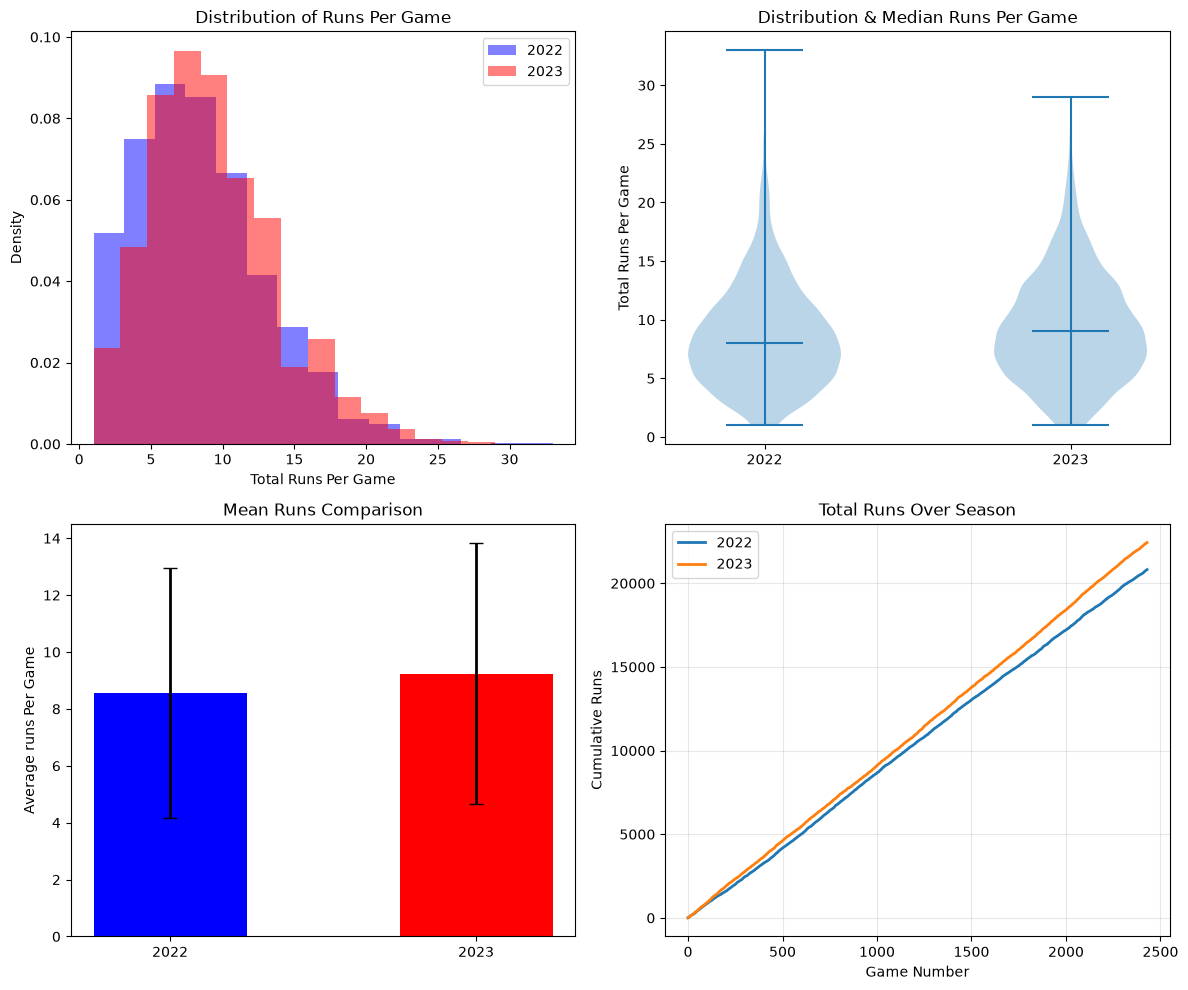

In [9]:
# Stats + Visualizations - Summary stats + 4 plots comparing years visually
def summary_statistics(df):
    """
    Calculate and print summary stats by year
    
    Args:
        df: dataframe of cleaned MLB games
    
    Returns:
        summary statistics of total_score by year
    """
    df = df.copy()

    summary_df = df.groupby('year').agg(
        n_games = ('total_score', 'count'),
        total_runs = ('total_score', 'sum'),
        avg_runs = ('total_score', 'mean'),
        std_runs = ('total_score', 'std')
    )

    return summary_df

def create_visualizations(df):
    """
    Create key visualizations
    
    Args:
        df: dataframe of cleaned MLB games
    
    Returns:
        histogram, box plot, bar chart
    """

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Histogram of runs/game
    axes[0,0].hist(df[df['year'] == 2022]['total_score'], 
                   bins=15, alpha=0.5,
                   label='2022', color='blue', density=True,)
    axes[0,0].hist(df[df['year'] == 2023]['total_score'], 
                   bins=15, alpha=0.5,
                   label='2023', color='red', density=True,)
    axes[0,0].set_xlabel('Total Runs Per Game')
    axes[0,0].set_ylabel('Density')
    axes[0,0].set_title('Distribution of Runs Per Game')
    axes[0,0].legend()

    # Violin plot of quartiles
    parts = axes[0,1].violinplot([df[df['year'] == 2022]['total_score'],
                                df[df['year'] == 2023]['total_score']],
                                positions=[0, 1], showmeans=False, showmedians=True)
    axes[0,1].set_xticks([0, 1])
    axes[0,1].set_xticklabels(['2022', '2023'])
    axes[0,1].set_ylabel('Total Runs Per Game')
    axes[0,1].set_title('Distribution & Median Runs Per Game')

    # Mean runs per year bar
    summary = summary_statistics(df)
    print("Summary dataframe:")
    print(summary)
    print("Index:", summary.index.tolist())
    axes[1,0].bar([0, 1], summary['avg_runs'],
                  yerr=summary['std_runs'],
                  color=['blue', 'red'],
                  width=0.5,
                  capsize=5,
                  error_kw={'elinewidth': 2, 'linewidth': 2})
    axes[1,0].set_ylabel('Average runs Per Game')
    axes[1,0].set_title('Mean Runs Comparison')
    axes[1,0].set_xticks([0, 1])
    axes[1,0].set_xticklabels(['2022', '2023'])

    # 4. Cumulative runs over season
    for year in [2022, 2023]:
        year_data = df[df['year'] == year].sort_values('date')
        axes[1,1].plot(range(len(year_data)), year_data['total_score'].cumsum(),
                    label=str(year), linewidth=2)
        axes[1,1].set_xlabel('Game Number')
        axes[1,1].set_ylabel('Cumulative Runs')
        axes[1,1].set_title('Total Runs Over Season')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../results/analysis.png')
    plt.show()

create_visualizations(df)

1) Histograms: Distribution of runs per game is shifted rightward (toward higher total runs) for 2023
2) Violins: Although 2022 has a higher maximum total runs in a game, 2023 has a higher median (middle line inside violin) as well as a heavier concentration in higher values relative to 2022
3) Mean runs per game is higher in 2023 than 2022, even given the large standard deviations
4) Beginning early in the season, 2023 shows a higher total amount of runs scored that mostly increases over time and is maintained through the last regular season game

Although this was not a controlled experiment, I wanted to include some simple statistical hypothesis testing regarding these results. 

In [10]:
# Run statistical assumptions for two-sample t-test, followed by the proper test(s)
def run_stats(df):
    df = df.copy()
    """
    Run simple stats tests
    
    Args:
        df: dataframe of cleaned MLB games
    
    Returns:
        Assumption checks and ttest results
    """

    # Separate samples
    runs_2022 = df[df['year'] == 2022]['total_score']
    runs_2023 = df[df['year'] == 2023]['total_score']

    # Test equal variance
    stat, p_value = levene(runs_2022, runs_2023)
    print(f"Levene's test p-value: {p_value:.4f}")
    if p_value > 0.05:
        print("✓ Equal variances assumption holds")
        t_stat, p_value = ttest_ind(runs_2022, runs_2023, equal_var=True)
        print("t-test:")
        print(f"    T-statistic: {t_stat:.4f}")
        print(f"    P-value: {p_value:.2e}")
    else:
        print("✗ Unequal variances - use Welch's t-test instead")
        t_stat, p_value = ttest_ind(runs_2022, runs_2023, equal_var=False)
        print("t-test:")
        print(f"    T-statistic: {t_stat:.4f}")
        print(f"    P-value: {p_value:.2e}")

    # Non-parametric test (doesn't assume normality)
    stat, p_value = mannwhitneyu(runs_2022, runs_2023, alternative='two-sided')
    print(f"Mann-Whitney U test:")
    print(f"    U-statistic: {stat:.2f}")
    print(f"    P-value: {p_value:.2e}")

run_stats(df)

Levene's test p-value: 0.0065
✗ Unequal variances - use Welch's t-test instead
t-test:
    T-statistic: -5.1603
    P-value: 2.56e-07
Mann-Whitney U test:
    U-statistic: 2689047.50
    P-value: 6.65e-08


1) There are assumptions that must be maintained in order for statistical testing to be properly implemented - for t-tests that includes independence of observations, equal variances, and normal distributions  
2) For the most part, individual baseball games are independent observations, though a case could be made for double-headers
3) The Levene's test, if significant (< 0.05), means the samples have unequal variances and a Welch's t-test must be used, which was the case here.
4) Our Welch's t-test was significant well below even a p < 0.01 level, meaning we can reject the null hypothesis that run-scoring was not different between the 2022 and 2023 MLB seasons.
5) Even though we can assume normality via the Central Limit Theorem with such a large sample, I wanted to include a nonparametric test because MLB run-scoring has a clear right-skewed distribution. This result was also significant well below p < 0.01 as well.

This significant finding must be taken with several grains of salt. First and foremost it does NOT mean that the rule changes caused more scoring in 2023. These data are observational in nature, and not part of a controlled experiment. Therefore, many other variables changed across the seasons, including weather, injuries, rosters, etc. that could certainly explain differences in scoring as well. 

## Conclusion
The 2023 MLB rule changes were associated with a statistically significant
increase in run scoring (+0.66 runs/game, 7.7% increase).

Both the Welch's t-test (p=2.56e-07) and Mann-Whitney U test (p=6.65e-08)
confirm this difference is highly unlikely due to random chance.

While we cannot definitively prove causation (observational study),
the timing and consistency make the rules the most likely explanation.